# **Modelo clasificatorio de calidad de champiñones**

In [1]:
# Instalación de librerías básicas
!pip install torch torchvision pandas numpy matplotlib scikit-learn seaborn

# **CARGAR DATOS Y ESTRATIFICACIÓN**

In [2]:
import pandas as pd

def load_data_from_github():
    try:
        #URLs Raw de archivos de github
        dataset_url = "https://raw.githubusercontent.com/VivianaPM/DL-VisNIR-QualityClassifier/refs/heads/feature/model-mushroom/Mushroom/Data/Dataset_Mus.csv"
        rangos_url = "https://raw.githubusercontent.com/VivianaPM/DL-VisNIR-QualityClassifier/refs/heads/feature/model-mushroom/Mushroom/Data/MushQualTags.csv"

        print("Cargando datos...")
        
        dataset = pd.read_csv(dataset_url, sep=',')
        rangos = pd.read_csv(rangos_url, sep=';')
        
        print(f"Dataset cargado: {dataset.shape}")
        print(f"Rangos cargados: {rangos.shape}")
        
        return dataset, rangos
        
    except Exception as e:
        print(f"Error: {e}")
        return None, None

## CARGAR DATOS DESDE GITHUB

In [3]:
df_Mush, rank_Mush = load_data_from_github()

if 'Dry matter' not in df_Mush.columns:
    print("Busca la columna equivalente a 'Dry matter' en:")
    print(df_Mush.columns.to_list())

Cargando datos...
Dataset cargado: (250, 206)
Rangos cargados: (6, 3)


In [4]:
display(rank_Mush)

,Category,Min_DryM,Max_DryM
0,Excelente,0.335,0.970
1,Muy buena,0.180,0.335
2,Buena,0.125,0.180
3,Razonable,0.089,0.125
4,Mala calidad,0.080,0.089
5,Muy mala,0.000,0.080


## ASIGNAR CATEGORÍA DEL MUSHQUALTAGS.CSV

In [5]:
def define_categories_mush(dry_matter, rank_Mush):
    for _, fila in rank_Mush.iterrows():
        if fila['Min_DryM'] <= dry_matter <= fila['Max_DryM']:
            return fila['Category']
    return 'Desconocida'

df_Mush['Category'] = df_Mush['Dry matter'].apply(
    lambda x: define_categories_mush(x, rank_Mush)
)

## DISTRIBUCIÓN DE CATEGORIAS

In [6]:
print(df_Mush['Category'].value_counts())

Category
Excelente       63
Razonable       62
Muy mala        51
Muy buena       36
Buena           26
Mala calidad    12
Name: count, dtype: int64


## CODIFICACIÓN TEMPORAL PARA ESTRATIFICAR

In [7]:
category_map_mush = {
    'Excelente': 0,
    'Razonable': 1,
    'Muy mala': 2,
    'Muy buena': 3,
    'Buena': 4,
    'Mala calidad': 5

}

df_Mush['strat_label'] = df_Mush['Category'].map(category_map_mush)

## Definición de X y Y globales

In [8]:
X = df_Mush.drop(columns=['Category', 'strat_label'])
y = df_Mush['strat_label']

## CHEKPOINT: REVISAR CODIFICACIÓN TEMPORAL

In [9]:
print(df_Mush[['Category', 'strat_label']].head())

       Category  strat_label
0  Mala calidad            5
1      Muy mala            2
2      Muy mala            2
3      Muy mala            2
4      Muy mala            2


# **DEFINICIÓN DE LA ARQUITECTURA DEL MLP**

In [10]:
import torch.nn as nn

class MLP_Mush(nn.Module):
    def __init__(self, input_size, hidden_layers, outputs_size, activation, dropout_rate=0.2):
        super().__init__()

        layers = []
        prev_size = input_size

        # Función de activación
        act_map = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid()
        }
        
        act = act_map[activation]

        # Hidden layers
        for h in hidden_layers:
            layers.append(nn.Linear(prev_size, h))
            layers.append(act)
            layers.append(nn.Dropout(dropout_rate))
            prev_size = h
        
        layers.append(nn.Linear(prev_size, outputs_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)
        

# **STRATIFIED K-FOLD**

In [11]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## CHECKPOINT: VALIDACIÓN DE FOLDS

In [12]:
from collections import defaultdict
import pandas as pd

fold_counts = []

for i, (train_idx, val_idx) in enumerate(
        skf.split(df_Mush, df_Mush['strat_label'])):

    print(f"\nFOLD {i+1}")

    train_counts = df_Mush.iloc[train_idx]['Category'].value_counts()
    val_counts   = df_Mush.iloc[val_idx]['Category'].value_counts()

    print("TRAIN\n", train_counts)
    print("VAL\n", val_counts)

    # Guardar ambos para luego promediar
    for cat in df_Mush['Category'].unique():

        fold_counts.append({
            "fold": i+1,
            "category": cat,
            "train_samples": train_counts.get(cat, 0),
            "val_samples": val_counts.get(cat, 0)
        })



FOLD 1
TRAIN
 Category
Excelente       51
Razonable       50
Muy mala        41
Muy buena       29
Buena           20
Mala calidad     9
Name: count, dtype: int64
VAL
 Category
Excelente       12
Razonable       12
Muy mala        10
Muy buena        7
Buena            6
Mala calidad     3
Name: count, dtype: int64

FOLD 2
TRAIN
 Category
Excelente       51
Razonable       50
Muy mala        41
Muy buena       28
Buena           21
Mala calidad     9
Name: count, dtype: int64
VAL
 Category
Razonable       12
Excelente       12
Muy mala        10
Muy buena        8
Buena            5
Mala calidad     3
Name: count, dtype: int64

FOLD 3
TRAIN
 Category
Excelente       50
Razonable       50
Muy mala        40
Muy buena       29
Buena           21
Mala calidad    10
Name: count, dtype: int64
VAL
 Category
Excelente       13
Razonable       12
Muy mala        11
Muy buena        7
Buena            5
Mala calidad     2
Name: count, dtype: int64

FOLD 4
TRAIN
 Category
Excelente       50
Raz

In [13]:
# Folds consolidados
fold_df = pd.DataFrame(fold_counts)
print(fold_df.head())

   fold      category  train_samples  val_samples
0     1  Mala calidad              9            3
1     1      Muy mala             41           10
2     1     Razonable             50           12
3     1         Buena             20            6
4     1     Muy buena             29            7


In [14]:
mean_df = fold_df.groupby("category")[["train_samples", "val_samples"]].mean().reset_index()

mean_df.to_csv("prom_muestras_clase.csv", index=False)

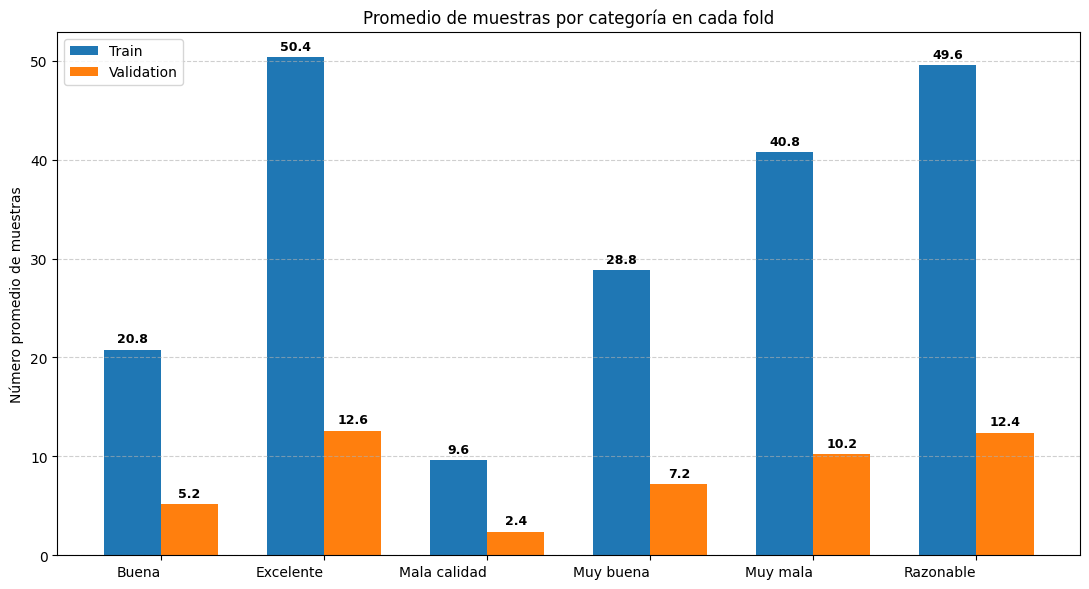

In [15]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(mean_df))
width = 0.35

plt.figure(figsize=(11,6))

# Barras
bars_train = plt.bar(
    x - width/2,
    mean_df["train_samples"],
    width,
    label="Train"
)

bars_val = plt.bar(
    x + width/2,
    mean_df["val_samples"],
    width,
    label="Validation"
)

# Etiquetas en cada barra
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(
            f'{height:.1f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),                 # desplazamiento vertical
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

autolabel(bars_train)
autolabel(bars_val)

# Ejes
plt.xticks(x, mean_df["category"], ha='right')
plt.ylabel("Número promedio de muestras")
plt.title("Promedio de muestras por categoría en cada fold")

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.legend()
plt.tight_layout()
plt.show()

# **ENTRENAMIENTO Y OPTIMIZACIÓN DEL MODELO**

## Diccionario de Optimizadores

In [16]:
import torch.optim as optim 

OPTIMIZERS = {
    # ADAM
    'adam': lambda params, lr: optim.Adam(params, lr=lr),
    # SGD
    'sgd': lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    # RMSprop
    'rmsprop': lambda params, lr: optim.RMSprop(params, lr=lr),
    # AdamW
    'adamW': lambda params, lr: optim.AdamW(params, lr=lr) 
}

## Dicionario de funciones de perdida

In [17]:
CRITERIONS = {
    # Entropia cruzada
    'cross_entropy': nn.CrossEntropyLoss, #Recomendada segun lo que he probado

    'weighted_ce': lambda w=None: nn.CrossEntropyLoss(weight=w),
    '''
    La pérdida de probabilidad logarítmica negativa. Es útil entrenar una clasificación problema con C clases. 
    (NLLLoss - Pytorch2.9 documentation, 2023)
    '''
    'nll': nn.NLLLoss,  
}

## FUNCIÓN DE ENTRENAMIENTO DEL MLP

In [18]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class Trainer:

    def __init__(self, model, device=None):

        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model.to(self.device)

        self.history = {
            'train_loss': [],
            'train_accuracy': [],
            'val_loss': [],
            'val_accuracy': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': []
        }

    # SETUP
    def setup(self, 
              optimizer_name='adam', 
              criterion_name='cross_entropy', 
              lr=1e-4, 
              class_weight=None):

        if optimizer_name not in OPTIMIZERS:
            raise ValueError(f"Optimizador no soportado: {optimizer_name}")

        self.optimizer = OPTIMIZERS[optimizer_name](self.model.parameters(), lr)

        # Criterion
        if criterion_name == "weighted_ce":
            self.criterion = CRITERIONS["weighted_ce"](class_weight)
        else:
            self.criterion = CRITERIONS[criterion_name]()

    # TRAIN 1 EPOCH
    def train_epoch(self, loader):
        self.model.train()

        total_loss = 0
        correct = 0
        total = 0

        for x, y in loader:
            x = x.to(self.device)
            y = y.to(self.device)

            self.optimizer.zero_grad()

            logits = self.model(x)
            loss = self.criterion(logits, y)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

        avg_loss = total_loss / len(loader)
        accuracy = correct / total

        return avg_loss, accuracy

    # VALIDATION
    def validate(self, loader):
        self.model.eval()

        total_loss = 0
        all_y = []
        all_pred = []

        with torch.no_grad():
            for x, y in loader:
                x = x.to(self.device)
                y = y.to(self.device)

                logits = self.model(x)
                loss = self.criterion(logits, y)

                preds = logits.argmax(dim=1)

                total_loss += loss.item()

                all_y.extend(y.cpu().numpy())
                all_pred.extend(preds.cpu().numpy())

        acc = accuracy_score(all_y, all_pred)
        prec = precision_score(all_y, all_pred, average='macro', zero_division=0)
        rec = recall_score(all_y, all_pred, average='macro', zero_division=0)
        f1 = f1_score(all_y, all_pred, average='macro', zero_division=0)

        return total_loss / len(loader), acc, prec, rec, f1

    # FULL TRAINING LOOP
    def train(self, train_loader, val_loader, epochs=50):

        for epoch in range(epochs):

            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, acc, prec, rec, f1 = self.validate(val_loader)

            self.history['train_loss'].append(train_loss)
            self.history['train_accuracy'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_accuracy'].append(acc)
            self.history['val_precision'].append(prec)
            self.history['val_recall'].append(rec)
            self.history['val_f1'].append(f1)

            if epoch % 10 == 0:
                print(
                    f"Epoch {epoch:03d} | "
                    f"Train: {train_loss:.3f} | "
                    f"Val: {val_loss:.3f} | "
                    f"Acc: {acc:.3f} | "
                    f"F1: {f1:.3f}"
                )

        return self.history
    
    # PREDICT FOR EVALUATION
    def predict(self, loader):

        self.model.eval()

        all_preds = []
        all_true = []

        with torch.no_grad():
            for x, y in loader:
                x = x.to(self.device)
                y = y.to(self.device)

                logits = self.model(x)
                preds = logits.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_true.extend(y.cpu().numpy())

        return all_true, all_preds    


## LISTA PARA METRICAS POR FOLD

## DICCIONARIO DE OVERSAMPLERS

In [19]:
from imblearn.over_sampling import RandomOverSampler, SMOTE #instalar

OVERSAMPLERS = {
    "none": None, #Sin oversampling
    "ros": RandomOverSampler,
    'smote': SMOTE

}

In [20]:
def apply_oversampling(X, y, method="none", random_state=42):

    if method == "none":
        return X, y
    
    if method not in OVERSAMPLERS:
        raise ValueError(f"Oversampler no soportado {method}")
    
    sampler = OVERSAMPLERS[method](random_state=random_state)

    X_res, Y_res = sampler.fit_resample(X, y)

    return X_res, Y_res

## CONFIGURACION DE MLP

In [21]:
MODEL_CONFIG = {
    # "Modelo_P1": {
    #     "hidden_layers": [64],
    #     "activation": 'sigmoid',
    #     "dropout": 0.35,
    #     "epochs": 150,
    #     "oversamplers": 'ros',
    #     # función de optimización
    #     "optimizer":'adam', 
    #     "criterion": 'cross_entropy', 
    #     "lr": 1e-4, 
    #     "class_weight": None
    # },

    # "Modelo_A1": {
    #     "hidden_layers": [128, 64],
    #     "activation": 'relu',
    #     "dropout": 0.4,
    #     "epochs": 150,
    #     "oversamplers": 'ros',
    #     # función de optimización
    #     "optimizer":'AdamW', 
    #     "criterion": 'cross_entropy', 
    #     "lr": 1e-4, 
    #     "class_weight": None
    # },

    "Modelo_A2": {
        "hidden_layers": [128, 84],
        "activation": 'relu',
        "dropout": 0.2,
        "epochs": 140,
        "oversamplers": 'smote',
        # función de optimización
        "optimizer":'adam', 
        "criterion": 'weighted_ce', 
        "lr": 5e-4, 
        "class_weight": None
    },

    # "Modelo_A3": {
    #     "hidden_layers": [128, 64],
    #     "activation": 'relu',
    #     "dropout": 0.35,
    #     "epochs": 150,
    #     "oversamplers": 'ros',
    #     # función de optimización
    #     "optimizer":'AdamW', 
    #     "criterion": 'cross_entropy', 
    #     "lr": 1e-4, 
    #     "class_weight": None
    # },   

    # "Modelo_A4": {
    #     "hidden_layers": [64],
    #     "activation": 'relu',
    #     "dropout": 0.45,
    #     "epochs": 120,
    #     "oversamplers": 'ros',
    #     # función de optimización
    #     "optimizer":'rmsprop', 
    #     "criterion": 'cross_entropy', 
    #     "lr": 1e-3, 
    #     "class_weight": None
    # },   

}

In [22]:
from  torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
# Revisar lo que tengo en x y y
# print("X: ", X.shape)
# print("Y: ", y.shape)

for model_name, config in MODEL_CONFIG.items():

    print(f"EJECUTANDO {model_name}")
    # Lista de metricas para folds
    metrics_all_folds_mush = []
    train_losses_all = []
    val_losses_all = []
    all_y_true = []
    all_y_pred = []


# loop del fold
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

        print(f"{'='*7} FOLD {fold} {'='*7}")

        #Paso #1: División del df_Mush
        X_train = X.iloc[train_idx]
        X_val   = X.iloc[val_idx]

        Y_train = y.iloc[train_idx]
        Y_val   = y.iloc[val_idx]  

        #Paso #2: Limpieza de las bandas
        spectral_bands = [c for c in X_train.columns if c not in ['Mush No']] 

        X_train_clean = X_train[spectral_bands]
        X_val_clean = X_val[spectral_bands]

        #Paso 4: Definición de los inputs de la red (Bandas espectrales)
        num_feactures = X_train_clean.shape[1]

        #Paso 5: Normalización - Buscando mejorar el rendimiento del modelo
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train_clean) 
        X_val_scaled = scaler.transform(X_val_clean)

        # Paso 6: OVERSAMPLING
        X_train_ros, Y_train_ros = apply_oversampling(
            X_train_scaled,
            Y_train,
            method=config['oversamplers']
        )

        # Paso 6.5 – Calcular pesos de clase
        classes = np.unique(Y_train_ros)
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=Y_train_ros
        )

        class_weights = torch.tensor(class_weights, dtype=torch.float32)  

        # Paso 7: Tensores
        X_train_tensor = torch.FloatTensor(X_train_ros)
        X_val_tensor = torch.FloatTensor(X_val_scaled)

        Y_train_tensor = torch.LongTensor(Y_train_ros.values)
        Y_val_tensor = torch.LongTensor(Y_val.values)

        # Paso 8: Creación de dataset y loader
        train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)

        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
        
        # Paso 9: Modelo + entrenamiento 
        model = MLP_Mush(
            input_size=num_feactures,
            hidden_layers=config['hidden_layers'],
            outputs_size=6,
            activation=config['activation'],       
            dropout_rate=config['dropout']    
        )

        trainer = Trainer(model)
        trainer.setup(config['optimizer'], config['criterion'], config['lr'], class_weights)

        history = trainer.train(
            train_loader=train_loader,
            val_loader=val_loader,
            epochs = config['epochs']
        )

        y_true, y_pred = trainer.predict(val_loader)

        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)

        # Paso 10: Guardar metricas
        for epoch in range(len(history['train_loss'])):

            metrics_all_folds_mush.append({
                "model": model_name,
                "fold": fold + 1,
                "epoch": epoch,

                "train_loss": history["train_loss"][epoch],
                "train_accuracy": history["train_accuracy"][epoch],

                "val_loss": history["val_loss"][epoch],
                "val_accuracy": history["val_accuracy"][epoch],
                "val_precision": history["val_precision"][epoch],
                "val_recall": history["val_recall"][epoch],
                "val_f1": history["val_f1"][epoch]               
            })

    #EXPORTAR CSV DE METRICAS POR MODELO 
    df = pd.DataFrame(metrics_all_folds_mush)

    csv_filename = f"metrics_{model_name}.csv"

    df.to_csv(csv_filename, index=False)

    print(f"CSV guardado: {csv_filename}")
    
    #EXPORTAR CSV PARA MATRIX DE CONFUSION 
    csv_filename_con = f"confusion_{model_name}.csv"

    pd.DataFrame({
        'y_true': all_y_true,
        'y_pred': all_y_pred
    }).to_csv(csv_filename_con, index=False)

    print(f"CSV guardado: {csv_filename_con}")

EJECUTANDO Modelo_A2
======= FOLD 1 =======
Epoch 000 | Train: 1.753 | Val: 1.678 | Acc: 0.340 | F1: 0.221
Epoch 010 | Train: 1.388 | Val: 1.311 | Acc: 0.480 | F1: 0.399
Epoch 020 | Train: 1.257 | Val: 1.234 | Acc: 0.480 | F1: 0.436
Epoch 030 | Train: 1.174 | Val: 1.218 | Acc: 0.480 | F1: 0.441
Epoch 040 | Train: 1.091 | Val: 1.174 | Acc: 0.460 | F1: 0.413
Epoch 050 | Train: 1.034 | Val: 1.111 | Acc: 0.520 | F1: 0.484
Epoch 060 | Train: 0.950 | Val: 1.084 | Acc: 0.520 | F1: 0.488
Epoch 070 | Train: 0.906 | Val: 1.006 | Acc: 0.540 | F1: 0.495
Epoch 080 | Train: 0.827 | Val: 0.991 | Acc: 0.580 | F1: 0.550
Epoch 090 | Train: 0.775 | Val: 0.904 | Acc: 0.640 | F1: 0.607
Epoch 100 | Train: 0.696 | Val: 0.780 | Acc: 0.660 | F1: 0.635
Epoch 110 | Train: 0.639 | Val: 0.724 | Acc: 0.720 | F1: 0.686
Epoch 120 | Train: 0.607 | Val: 0.764 | Acc: 0.760 | F1: 0.719
Epoch 130 | Train: 0.601 | Val: 0.694 | Acc: 0.820 | F1: 0.807
======= FOLD 2 =======
Epoch 000 | Train: 1.765 | Val: 1.676 | Acc: 0.400 

## PROMEDIO POR METRICAS DE MODELO

In [23]:
import pandas as pd

def calcular_promedios_por_modelo(csv_path):

    df = pd.read_csv(csv_path)

    last_epochs = df.groupby("fold").tail(1)

    mean_metrics = last_epochs[
        ["val_accuracy", "val_precision", "val_recall", "val_f1"]
    ].mean()

    return mean_metrics

# re_m1 = calcular_promedios_por_modelo("metrics_Modelo_P1.csv")
# re_m2 = calcular_promedios_por_modelo("metrics_Modelo_A1.csv")
re_m3 = calcular_promedios_por_modelo("metrics_Modelo_A2.csv")
# re_m4 = calcular_promedios_por_modelo("metrics_Modelo_A3.csv")
# re_m5 = calcular_promedios_por_modelo("metrics_Modelo_A4.csv")

# print("metrics_Modelo_P1")
# print(re_m1)
# print("\nmetrics_Modelo_A1")
# print(re_m2)
print("\nmetrics_Modelo_A2")
print(re_m3)
# print("\nmetrics_Modelo_A3")
# print(re_m4)
# print("\nmetrics_Modelo_A4")
# print(re_m5)



metrics_Modelo_A2
val_accuracy     0.724000
val_precision    0.663545
val_recall       0.683243
val_f1           0.653792
dtype: float64


## GRAFICOS: TRAIN VS VAL (LOSS Y ACCUARY)

Graficas para el A2


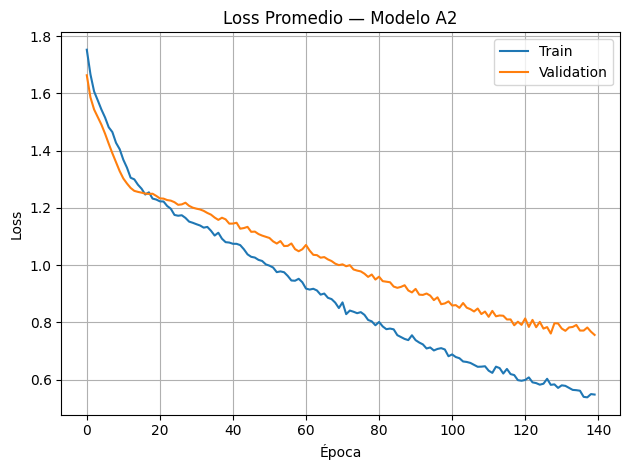

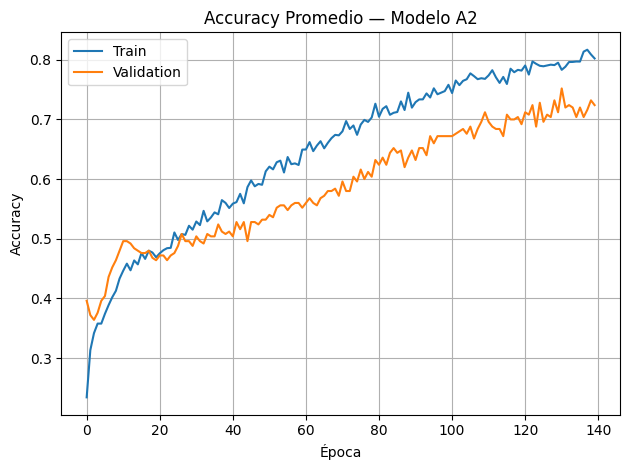

In [ ]:
model_files = {
    # "P1": "metrics_Modelo_Propuesta_1.csv",
    # "A1": "metrics_Modelo_A1.csv",
    "A2": "metrics_Modelo_A2.csv",
    # "A3": "metrics_Modelo_A3.csv",
    # "A4": "metrics_Modelo_A4.csv",
}

def plot_model_metrics(model_name, csv_path):

    df = pd.read_csv(csv_path)

    # Promedio por época (consolidando folds)
    mean_epoch = df.groupby("epoch").mean(numeric_only=True)

    #LOSS 
    plt.figure()

    plt.plot(mean_epoch["train_loss"], label="Train")
    plt.plot(mean_epoch["val_loss"], label="Validation")

    plt.title(f"Loss Promedio — Modelo {model_name}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    # ACCURACY 
    if "train_accuracy" in mean_epoch.columns:

        plt.figure()

        plt.plot(mean_epoch["train_accuracy"], label="Train")
        plt.plot(mean_epoch["val_accuracy"], label="Validation")

        plt.title(f"Accuracy Promedio — Modelo {model_name}")
        plt.xlabel("Época")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

# EJECUCIÓN AUTOMÁTICA

for model_name, csv_file in model_files.items():
    print(f"Graficas para el modelo {model_name}")
    plot_model_metrics(model_name, csv_file)

## GRAFICO DE MARTRIZ DE CONFUSIÓN

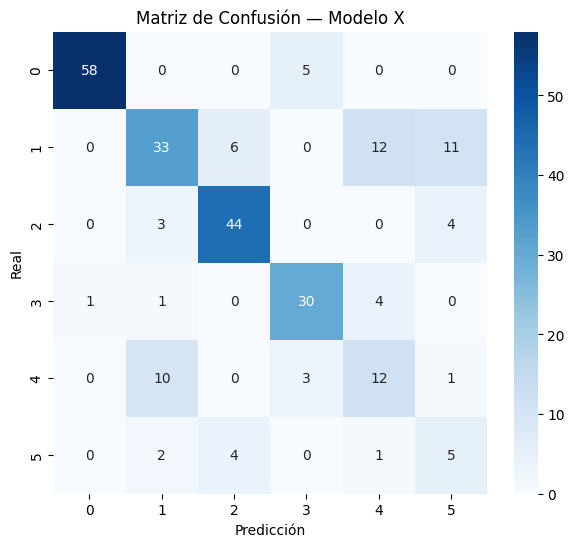

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("confusion_Modelo_A2.csv")

cm = confusion_matrix(df['y_true'], df['y_pred'])

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión — Modelo X")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()